# **1. Palo Alto Networks Dataset**

In [170]:
import pandas as pd

df = pd.read_excel("Palo Alto Networks.xlsx")

print(df.head())
print(df.shape)

   Age  Attrition     BusinessTravel  DailyRate              Department  \
0   41          1      Travel_Rarely       1102                   Sales   
1   49          0  Travel_Frequently        279  Research & Development   
2   37          1      Travel_Rarely       1373  Research & Development   
3   33          0  Travel_Frequently       1392  Research & Development   
4   27          0      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
0                 1          2  Life Sciences                        2   
1                 8          1  Life Sciences                        3   
2                 2          2          Other                        4   
3                 3          4  Life Sciences                        4   
4                 2          1        Medical                        1   

   Gender  ...  PerformanceRating  RelationshipSatisfaction  StockOptionLevel  \
0  Female  ...         

#**2. Understanding The Data**

In [ ]:
print(df.info())
print(df.describe())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

#**3. Data Cleaning**

**3.1 Missing Values**

In [180]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64


**3.2 Convert Attrition**

In [172]:
print(df['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


#**4. KPI ANALYSIS**

**4.1 Overall Attrition**

In [173]:
# The 'Attrition' column is now in its original numeric format (0 for No, 1 for Yes)
# after reloading the DataFrame. No further transformation is needed for this column.

total_employees = df.shape[0]
employees_who_left = df['Attrition'].sum()

attrition_rate = (employees_who_left / total_employees) * 100
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


**4.2 Department wise**

In [177]:
dept_attrition = df.groupby('Department')['Attrition'].mean()*100
print(dept_attrition)

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64


**4.3 Job Role wise**

In [178]:
role_attrition = df.groupby('JobRole')['Attrition'].mean()*100
print(role_attrition)

JobRole
Healthcare Representative     6.870229
Human Resources              23.076923
Laboratory Technician        23.938224
Manager                       4.901961
Manufacturing Director        6.896552
Research Director             2.500000
Research Scientist           16.095890
Sales Executive              17.484663
Sales Representative         39.759036
Name: Attrition, dtype: float64


**4.4 Gebder wise**

In [179]:
gender_attrition = df.groupby('Gender')['Attrition'].mean()*100
print(gender_attrition)

Gender
Female    14.795918
Male      17.006803
Name: Attrition, dtype: float64


**4.5 Overtime impact**

In [ ]:
ot_attrition = df.groupby('OverTime')['Attrition'].mean()*100
print(ot_attrition)

OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64


**4.6 Travel Impact**

In [ ]:
travel_attrition = df.groupby('BusinessTravel')['Attrition'].mean()*100
print(travel_attrition)

BusinessTravel
Non-Travel            8.000000
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Name: Attrition, dtype: float64


#**5. AGE ANALYSIS**

**Create Age Group**

In [ ]:
df['AgeGroup'] = pd.cut(df['Age'],
                       bins=[18,25,35,50,60],
                       labels=['18-25','26-35','36-50','50+'])

print(df['AgeGroup'].value_counts())

AgeGroup
26-35    606
36-50    598
50+      143
18-25    115
Name: count, dtype: int64


**Calculate**

In [ ]:
age_attrition = df.groupby('AgeGroup')['Attrition'].mean()*100
print(age_attrition)

AgeGroup
18-25    34.782609
26-35    19.141914
36-50     9.866221
50+      12.587413
Name: Attrition, dtype: float64


/tmp/ipykernel_3233/2449092639.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attrition = df.groupby('AgeGroup')['Attrition'].mean()*100


#**6. TENURE ANALYSIS**

In [ ]:
df['TenureGroup'] = pd.cut(df['YearsAtCompany'],
                          bins=[0,2,5,10,40],
                          labels=['0-2','3-5','6-10','10+'])

tenure_attrition = df.groupby('TenureGroup')['Attrition'].mean()*100
print(tenure_attrition)

TenureGroup
0-2     28.859060
3-5     13.824885
6-10    12.276786
10+      8.130081
Name: Attrition, dtype: float64


/tmp/ipykernel_3233/3025064303.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_attrition = df.groupby('TenureGroup')['Attrition'].mean()*100


#**7. VISUALIZATION**

**BAR CHART**

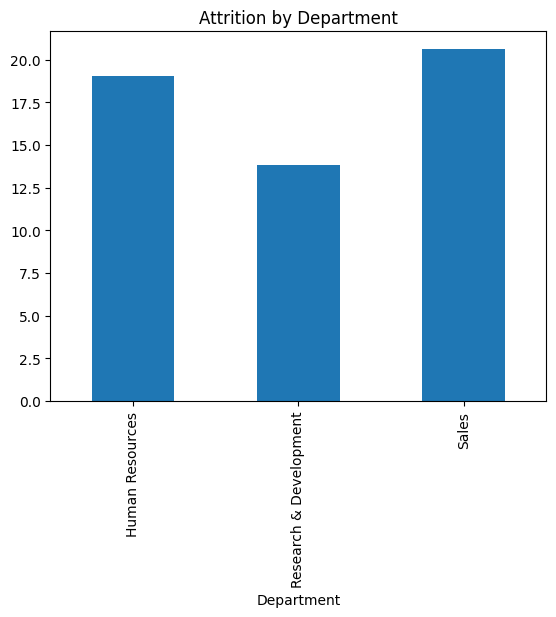

In [ ]:
import matplotlib.pyplot as plt

dept_attrition.plot(kind='bar')
plt.title("Attrition by Department")
plt.show()

**HEATMAP**

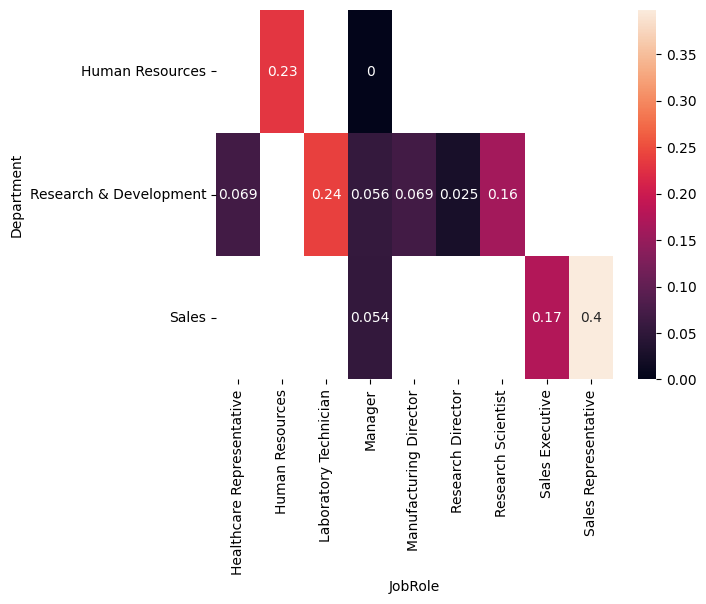

In [ ]:
import seaborn as sns

heatmap_data = df.pivot_table(values='Attrition',
                             index='Department',
                             columns='JobRole')

sns.heatmap(heatmap_data, annot=True)
plt.show()